In [1]:
%load_ext autoreload
%autoreload 2

In [21]:
import paris_2025 as p
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from windrose import WindroseAxes
import numpy as np
import ggpymanager as ggpy
import hvplot.xarray
import pandas as pd
import seaborn as sns

In [3]:
YEAR = 2023

In [9]:
# Set matplotlib style like size of the figures, text size, etc. by hand
sns.set_context("paper", font_scale=1)
plt.rcParams.update(
    {
        "figure.figsize": (7, 5),
        # "axes.titlesize": 16,
        # "axes.labelsize": 14,
        # "xtick.labelsize": 12,
        # "ytick.labelsize": 12,
        # "legend.fontsize": 12,
        # "lines.linewidth": 1.5,
        # "grid.linewidth": 0.5,
        # "grid.alpha": 0.5,
        # "font.family": "sans-serif",
        # "font.sans-serif": "Arial",
        # "axes.grid": True,
        # "axes.spines.right": False,
        # "axes.spines.top": False,
    }
)

In [16]:
plotting_params = sns.plotting_context()
plotting_params

{'font.size': 9.600000000000001,
 'axes.labelsize': 9.600000000000001,
 'axes.titlesize': 9.600000000000001,
 'xtick.labelsize': 8.8,
 'ytick.labelsize': 8.8,
 'legend.fontsize': 8.8,
 'legend.title_fontsize': 9.600000000000001,
 'axes.linewidth': 1.0,
 'grid.linewidth': 0.8,
 'lines.linewidth': 1.2000000000000002,
 'lines.markersize': 4.800000000000001,
 'patch.linewidth': 0.8,
 'xtick.major.width': 1.0,
 'ytick.major.width': 1.0,
 'xtick.minor.width': 0.8,
 'ytick.minor.width': 0.8,
 'xtick.major.size': 4.800000000000001,
 'ytick.major.size': 4.800000000000001,
 'xtick.minor.size': 3.2,
 'ytick.minor.size': 3.2}

In [5]:
meteo = p.meteo.get_meteo_measurements().sel(time=str(YEAR))

# Meteo

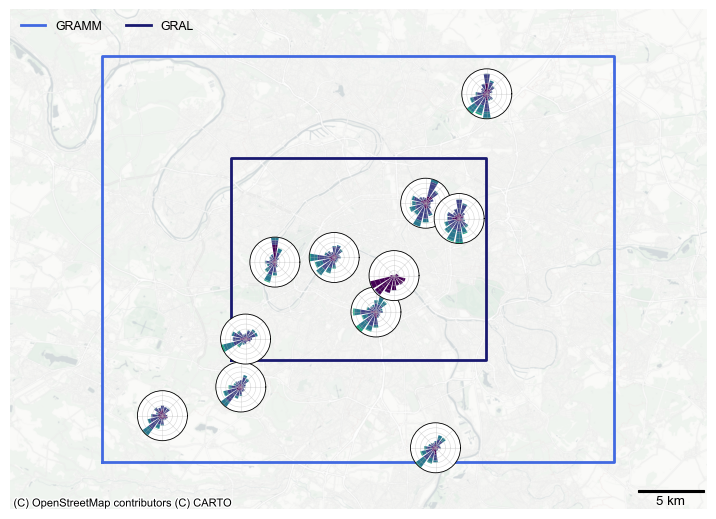

In [29]:
fig, ax = plt.subplots()
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
p.domain.add_domain(ax, legend=True)
p.domain.add_basemap(ax, zoom=12, provider="CartoDB")
p.domain.add_size_bar(ax)

with mpl.rc_context(
    {
        "grid.linewidth": plotting_params["grid.linewidth"] * 0.5,
        "axes.linewidth": plotting_params["lines.linewidth"] * 0.5,
    }
):
    for i, station in enumerate(meteo.where(meteo.in_gramm_domain, drop=True).station):
        data = meteo.sel(station=station)
        mask = (data.wind_speed.notnull()) & (data.wind_direction.notnull())
        if mask.sum() / len(mask) < 0.5:
            continue
        wrax = inset_axes(
            ax,
            width=0.5,
            height=0.5,
            loc="center",
            bbox_to_anchor=(data.x, data.y),
            bbox_transform=ax.transData,
            axes_class=WindroseAxes,
        )
        wrax.bar(
            data.wind_direction[mask].values,
            data.wind_speed[mask].values,
            normed=True,
            opening=0.8,
        )
        wrax.set_xlabel("")
        wrax.set_ylabel("")
        wrax.set_xticklabels([])
        wrax.set_yticklabels([])
plt.savefig("../figures/wind_measurements.pdf")